# FloodRisk is a classification problem.
# This notebook demonstrates Logistic Regression
# for predicting flood risk categories.

In [4]:
# Import Libraries

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [5]:
#Load Dataset

df = pd.read_csv('../data/raw/flood_data.csv')

In [6]:
# Select features and target

X = df[['rainfall', 'humidity', 'temperature']]
y = df['flood_risk']

In [7]:
# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [8]:
# Majority Class Baseline

baseline = DummyClassifier(strategy='most_frequent')

baseline.fit(X_train, y_train)

baseline_preds = baseline.predict(X_test)
baseline_probs = baseline.predict_proba(X_test)[:, 1]

In [9]:
# Train Logistic Regression Model

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not wo

In [10]:
# Make Predictions

predictions = pipeline.predict(X_test)

probabilities = pipeline.predict_proba(X_test)[:, 1]

In [11]:
# Evaluate using Accuracy

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [12]:
# Classification Report

from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00         5

    accuracy                           1.00        11
   macro avg       1.00      1.00      1.00        11
weighted avg       1.00      1.00      1.00        11



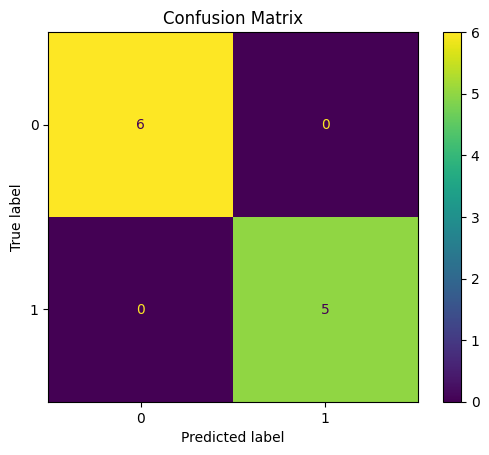

In [13]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Confusion Matrix")

plt.show()

In [14]:
# Majority Class Baseline Comparison

from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(strategy='most_frequent')

baseline.fit(X_train, y_train)

baseline_preds = baseline.predict(X_test)

baseline_accuracy = accuracy_score(y_test, baseline_preds)

model_accuracy = accuracy_score(y_test, predictions)

print("Baseline Accuracy:", baseline_accuracy)

print("Logistic Regression Accuracy:", model_accuracy)

Baseline Accuracy: 0.5454545454545454
Logistic Regression Accuracy: 1.0


In [15]:
# Balanced Accuracy

from sklearn.metrics import balanced_accuracy_score

balanced_acc = balanced_accuracy_score(
    y_test,
    predictions
)

print("Balanced Accuracy:", balanced_acc)

Balanced Accuracy: 1.0


In [16]:
# Cross Validation Accuracy

from sklearn.model_selection import cross_val_score
import numpy as np

cv_scores = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("CV Accuracy Scores:", cv_scores)

print("Mean CV Accuracy:",
      cv_scores.mean())

print("Std CV Accuracy:",
      cv_scores.std())

CV Accuracy Scores: [1. 1. 1. 1. 1.]
Mean CV Accuracy: 1.0
Std CV Accuracy: 0.0


In [17]:
# Coefficients Interpretation

model = pipeline.named_steps['model']

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0],
    'Odds Ratio': np.exp(model.coef_[0])
})

print(coefficients)

       Feature  Coefficient  Odds Ratio
0     rainfall     1.221841    3.393429
1     humidity     1.366286    3.920760
2  temperature     1.211916    3.359917
